Используется датасет с пассажирами титаника


**Кластеризация** - задача разбиения заданной выборки объектов на непересекающиеся подмножества, называемые кластерами, так, чтобы каждый кластер состоял из схожих объектов, а объекты разных кластеров существенно отличались. Под схожестью обычно понимается близость друг к другу относительно выбранной метрики.

**Для чего используется кластеризация?**

- Понимание данных путём выявления кластерной структуры. Разбиение выборки на группы позволяет понять структуру данных исследуемой предметной области. - Разбиение выборки на группы схожих объектов позволяет упростить дальнейшую обработку данных и принятия решений, применяя к каждому кластеру свой метод анализа.
- Обнаружение новизны. Выделяются нетипичные объекты, которые не удаётся присоединить ни к одному из кластеров.

In [ ]:
import pandas as pd

In [ ]:
titanic_train = pd.read_csv('./titanic_train.csv')

In [ ]:
titanic_test = pd.read_csv('./titanic_test.csv')

In [ ]:
titanic_train.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
titanic_test.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

titanic_train = pd.get_dummies(titanic_train, columns=['Sex', 'Embarked'])
titanic_test = pd.get_dummies(titanic_test, columns=['Sex', 'Embarked'])

titanic_train.drop(columns=['Sex_male'], axis=1, inplace=True)
titanic_test.drop(columns=['Sex_male'], axis=1, inplace=True)

In [ ]:
titanic_train_knn = titanic_train.copy(deep=True)
titanic_test_knn = titanic_test.copy(deep=True)

from sklearn.impute import KNNImputer

imputer = KNNImputer()
titanic_train_knn = imputer.fit_transform(titanic_train_knn)
titanic_test_knn = imputer.fit_transform(titanic_test_knn)

titanic_train = pd.DataFrame(data=titanic_train_knn, columns=['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])
titanic_test = pd.DataFrame(data=titanic_test_knn, columns=['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])

In [ ]:
titanic_train.drop(columns=['Fare'], axis=1, inplace=True)
titanic_test.drop(columns=['Fare'], axis=1, inplace=True)

In [ ]:
X_titanic =  titanic_train.drop(columns=['Survived', 'PassengerId'])
y_titanic = titanic_train['Survived']

In [ ]:
X_titanic_test = titanic_test.drop(columns=['PassengerId'])

Используем KMeans и AgglomerativeClustering

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

In [ ]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from sklearn.metrics import homogeneity_completeness_v_measure

##Метрики качества кластеризации
### Adjusted Rand index

Метрика применяется в том случае, если известны истинные метки классов. Для вычисления метрики используется функция. Метрика схожа с accuracy, так как сравнивает полученные метки классов с известными истинными классами.

Метрика возвращает результат в диапазоне [-1; +1]. Значение близкое к +1 говорит об очень хорошем качестве кластеризации. Значение близкое к 0 соответствует случайным разбиениям. Отрицательные значения говорят о плохом качестве кластеризации.

### Adjusted Mutual Information

Значение близкое к +1 говорит об очень хорошем качестве кластеризации. Значение близкое к 0 соответствует случайным разбиениям.

### Homogeneity, completeness, V-measure

- Homogeneity - каждый кластер содержит только представителей единственного класса (под классом понимается истинное значение метки кластера). Значение в диапазоне [0;1], 1 говорит об очень хорошем качестве кластеризации.
- Completeness - все элементы одного класса помещены в один и тот же кластер. Значение в диапазоне [0;1], 1 говорит об очень хорошем качестве кластеризации.
- V-measure - среднее гармоническое от Homogeneity и Completeness.

### Коэффициент силуэта

Данный метод не требует знания истинных значений меток кластеров.

Пусть:

- $a$ - среднее расстояние между текущей точкой и другими точками этого же кластера.
- $b$ - среднее расстояние между текущей точкой и другими точками следующего ближайшего кластера.

Тогда коэффициент силуэта для точки (объекта) определяется как:

$$ s = \frac{b-a}{max(a,b)} $$

Силуэтом выборки называется средняя величина силуэта объектов данной выборки. Таким образом, силуэт показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров.

Данная величина лежит в диапазоне [-1;1]. Значения, близкие к -1, соответствуют плохим (разрозненным) кластеризациям, значения, близкие к нулю, говорят о том, что кластеры пересекаются и накладываются друг на друга, значения, близкие к 1, соответствуют "плотным" четко выделенным кластерам. Таким образом, чем больше силуэт, тем более четко выделены кластеры, и они представляют собой компактные, плотно сгруппированные облака точек.

С помощью силуэта можно выбирать оптимальное число кластеров
(если оно заранее неизвестно) — выбирается число кластеров, максимизирующее значение силуэта. В отличие от предыдущих метрик, силуэт зависит от формы кластеров, и достигает больших значений на более выпуклых кластерах, получаемых с помощью алгоритмов, основанных на восстановлении плотности распределения.

## Метод k-средних

Алгоритм основан на **минимизации отклонения** точек кластеров от центров этих кластеров.

Формально, необходимо найти такую величину $$ \underset{s}{\mathrm{argmin}}\sum_{i = 1}^{k}\sum_{x \in S_{i}}\left| \left| x-\mu_{i} \right| \right|^{2}$$ где $S$ - кластер, $ μ$ - среднее всех точек кластера $S$, а $k $ - количество кластеров соответственно.
  
Шаги алгоритма:<br>
1) Генерируем или выбираем из уже существующих $k$ случайных точек, которые будут центрами кластеров.<br>
2) Цикл:<br>
    a) Отнесем каждый объект к ближайшему для него кластеру.<br>
    b) Пересчитываем координаты центров кластеров.  <br>

Повторяем a) и b) этапы пока положение центра кластеров не стабилизируется.


Для определения ближайшего кластера необходимо использовать какую-нибудь метрику $ \rho\left( x_{i}, x_{j} \right) $.
Наиболее простой является евклидова метрика, но применимо так же и манхэттенское расстояние и расстояние Махаланобиса.
$$\left| \left| x_{i} - x_{j} \right| \right|^{2} = \sum_{k = 1}^{n}\left( x^{k}_{i} - x^{k}_{j} \right)^{2}$$

In [ ]:
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X_titanic)


print("Kmeans")
ars = adjusted_rand_score(y_titanic, labels)
print(f"Adjusted Rand Score: {ars}")

amis = adjusted_mutual_info_score(y_titanic, labels)
print(f"Adjusted Mutual Info Score: {amis}")

homo_score = homogeneity_completeness_v_measure(y_titanic, labels)
print(f"Homogenity Competiveness V-Meassure Score: {homo_score}")

sil_score = silhouette_score(X_titanic, labels)
print(f"Silhoette score: {sil_score}")

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Kmeans
Adjusted Rand Score: -0.0031617035301381787
Adjusted Mutual Info Score: -0.001390521982783728
Homogenity Competiveness V-Meassure Score: (8.702806504920942e-05, 9.697539531328485e-05, 9.17328510547686e-05)
Silhoette score: 0.5474588466285116


In [ ]:
agglomerative_cluster = AgglomerativeClustering(n_clusters=2)
labels = agglomerative_cluster.fit_predict(X_titanic)

print("Agglomerative Clustering")
ars = adjusted_rand_score(y_titanic, labels)
print(f"Adjusted Rand Score: {ars}")

amis = adjusted_mutual_info_score(y_titanic, labels)
print(f"Adjusted Mutual Info Score: {amis}")

homo_score = homogeneity_completeness_v_measure(y_titanic, labels)
print(f"Homogenity Competiveness V-Meassure Score: {homo_score}")

sil_score = silhouette_score(X_titanic, labels)
print(f"Silhoette score: {sil_score}")

Agglomerative Clustering
Adjusted Rand Score: -0.002867078738939287
Adjusted Mutual Info Score: -0.0015504569224696744
Homogenity Competiveness V-Meassure Score: (5.3044879311990404e-05, 7.088206440753976e-05, 6.0679791480892205e-05)
Silhoette score: 0.5746510708746008


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

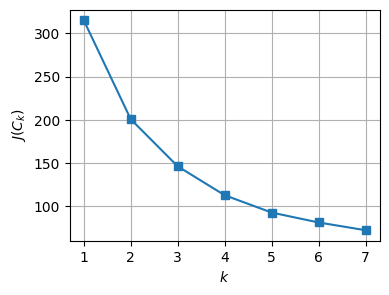

In [ ]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(X_titanic)
    inertia.append(np.sqrt(kmeans.inertia_))
plt.figure(figsize=(4,3))
plt.plot(range(1, 8), inertia, marker='s')
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$')
plt.grid()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=7, init='random')
kmeans.fit(X_titanic)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(init='random', n_clusters=7)

Для выбора количества кластеров можно использовать **правило локтя**.

Если $C$ – множество кластеров мощности $K$, а $\mu_k$ – центроид кластера  $C_k$, то инерция (сумма квадратов расстояний от точек до центроидов кластеров) вычисляется по следующей формуле:

$$ J(C) = \sum\limits_{k=1}^{K} \sum\limits_{i \in C_k} (x_i - \mu_k)^2 $$

Инерцию необходимо минимизировать по количеству кластеров:

$$ J(C) \rightarrow min_C  $$

Используется следующее решение -  выбирают такое число кластеров, начиная с которого уменьшение $J(C)$ замедляется:

$$ \frac{J(C_k) - J(C_{k+1})}{J(C_{k-1}) - J(C_k)} \rightarrow min_k $$

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

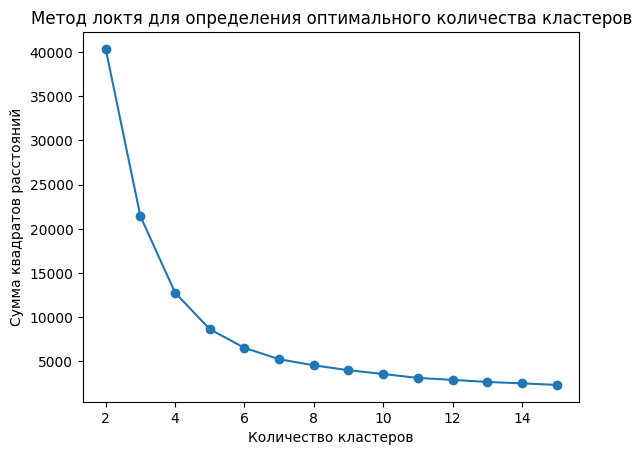

Оптимальное количество кластеров: 4
Adjusted Mutual Info Score: 0.00852090179073765
Adjusted Rand Score: 0.009009525435450555
Homogenity Competiveness V-Meassure Score: (5.3044879311990404e-05, 7.088206440753976e-05, 6.0679791480892205e-05)
Silhouette score: 0.5474588466285116


In [ ]:
sse = []
rand_scores = []
slt_scores = []
homo_scores = []
mutual_rand_scores = []

k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_titanic)
    sse.append(kmeans.inertia_)
    kmeans_pred = kmeans.predict(X_titanic)
    rand_scores.append(adjusted_rand_score(y_titanic, kmeans_pred))
    slt_scores.append(silhouette_score(X_titanic, kmeans_pred))
    mutual_rand_scores.append(adjusted_mutual_info_score(y_titanic, kmeans_pred))
    homo_scores.append(homogeneity_completeness_v_measure(y_titanic, kmeans_pred))

# Строим график суммы квадратов расстояний от количества кластеров
plt.plot(k_range, sse, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.show()

optimal_k_means = k_range[np.argmax(rand_scores)]
print("Оптимальное количество кластеров:", optimal_k_means)
print(f"Adjusted Mutual Info Score: {max(mutual_rand_scores)}")
print(f"Adjusted Rand Score: {max(rand_scores)}")
print(f"Homogenity Competiveness V-Meassure Score: {homo_score}")
print(f"Silhouette score: {max(slt_scores)}")

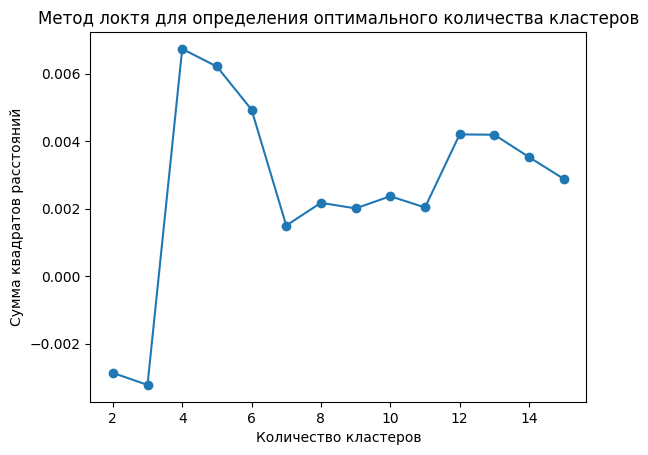

Оптимальное количество кластеров: 4
Adjusted Mutual Info Score: 0.003940904957482856
Adjusted Rand Score: 0.006730114659314545
Homogenity Competiveness V-Meassure Score: (5.3044879311990404e-05, 7.088206440753976e-05, 6.0679791480892205e-05)
Silhouette score: 0.5746510708746008


In [ ]:
rand_scores = []
slt_scores = []
homo_scores = []
mutual_rand_scores = []

k_range = range(2, 16)

for k in k_range:
    agg_model = AgglomerativeClustering(n_clusters=k)
    agg_model.fit(X_titanic)
    agg_model_pred = agg_model.labels_
    rand_scores.append(adjusted_rand_score(y_titanic, agg_model_pred))
    slt_scores.append(silhouette_score(X_titanic, agg_model_pred))
    mutual_rand_scores.append(adjusted_mutual_info_score(y_titanic, agg_model_pred))
    homo_scores.append(homogeneity_completeness_v_measure(y_titanic, agg_model_pred))

# Строим график суммы квадратов расстояний от количества кластеров
plt.plot(k_range, rand_scores, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.show()

optimal_k_agg = k_range[np.argmax(rand_scores)]
print("Оптимальное количество кластеров:", optimal_k_agg)
print(f"Adjusted Mutual Info Score: {max(mutual_rand_scores)}")
print(f"Adjusted Rand Score: {max(rand_scores)}")
print(f"Homogenity Competiveness V-Meassure Score: {homo_score}")
print(f"Silhouette score: {max(slt_scores)}")

In [ ]:
from sklearn.manifold import TSNE

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


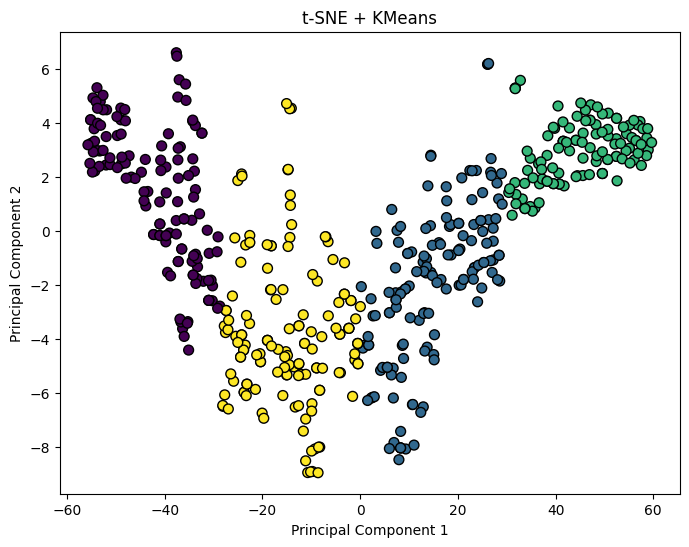

In [ ]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_titanic)

agg_model = KMeans(n_clusters=4)
labels = agg_model.fit_predict(X_tsne)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('t-SNE + KMeans')
plt.show()

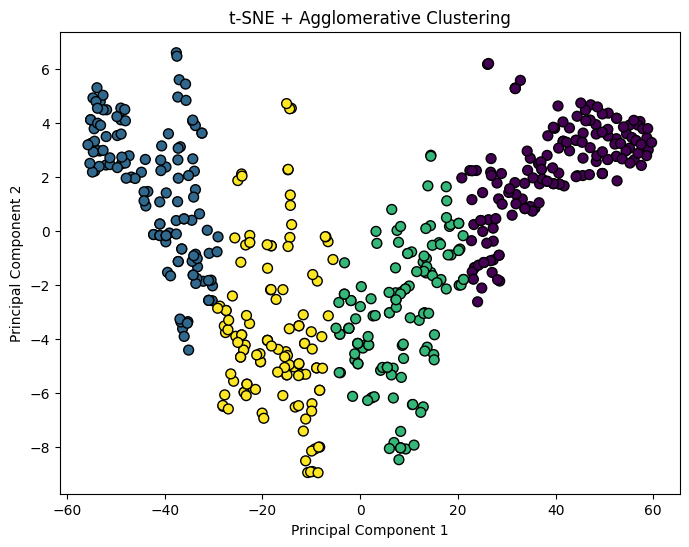

In [ ]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_titanic)

agg_model = AgglomerativeClustering(n_clusters=4)
labels = agg_model.fit_predict(X_tsne)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('t-SNE + Agglomerative Clustering')
plt.show()